In [22]:
import cv2
import json
from matplotlib import pyplot as plt
import numpy as np
import os
import random

# import a lot of things from keras:
# sequential model
from keras.models import Sequential

# layers
from keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, RandomFlip, RandomRotation, RandomContrast, RandomBrightness

# loss function
from keras.metrics import categorical_crossentropy

# callback functions
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

# convert data to categorial vector representation
from keras.utils import to_categorical

# nice progress bar for loading data
from tqdm.notebook import tqdm

# helper function for train/test split
from sklearn.model_selection import train_test_split

# import confusion matrix helper function
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# import pre-trained model
from keras.applications.vgg16 import VGG16

# include only those gestures
CONDITIONS = ['like', 'stop']

# image size
IMG_SIZE = 64
SIZE = (IMG_SIZE, IMG_SIZE)

# number of color channels we want to use
# set to 1 to convert to grayscale
# set to 3 to use color images
COLOR_CHANNELS = 3

## helper function to load and parse annotations

In [41]:
annotations = dict()

for condition in CONDITIONS:
    with open(f'../data/_annotations/{condition}.json') as f:
        annotations[condition] = json.load(f)

In [42]:
# pretty-print first element
# print(json.dumps(annotations['like']['000484ab-5fd0-49b8-9253-23a22b71d7b1'], indent=2))
print(json.dumps(annotations['like']['0014182f-d756-42b3-896c-c52de76926bb'], indent=2))

{
  "bboxes": [
    [
      0.38056273,
      0.35650891,
      0.17322347,
      0.10461114
    ]
  ],
  "labels": [
    "like"
  ],
  "landmarks": [
    [
      [
        0.5497169170918876,
        0.4276043615779976
      ],
      [
        0.5218336293004483,
        0.40536586667786917
      ],
      [
        0.48288133220125257,
        0.3930262243722419
      ],
      [
        0.4501841862302019,
        0.37981099195030416
      ],
      [
        0.44251365410099686,
        0.36620499322043343
      ],
      [
        0.43138297470865106,
        0.406093902776592
      ],
      [
        0.4072660997339628,
        0.4073950234480344
      ],
      [
        0.42588200316326846,
        0.40612291879594015
      ],
      [
        0.4441470003072778,
        0.4049221293588555
      ],
      [
        0.4314493576491367,
        0.4212979654419442
      ],
      [
        0.42096276272263283,
        0.4180224457320293
      ],
      [
        0.43966095717106257,
      

## helper function to pre-process images (color channel conversion and resizing)

In [25]:
def preprocess_image(img):
    if COLOR_CHANNELS == 1:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img, SIZE)
    return img_resized

## load images and annotations

In [44]:
images = [] # stores actual image data
labels = [] # stores labels (as integer - because this is what our network needs)
label_names = [] # maps label ints to their actual categories so we can understand predictions later

# loop over all conditions
# loop over all files in the condition's directory
# read the image and corresponding annotation
# crop image to the region of interest
# preprocess image
# store preprocessed image and label in corresponding lists
for condition in CONDITIONS:
    for filename in tqdm(os.listdir(f'../data/{condition}')):
        # extract unique ID from file name
        UID = filename.split('.')[0]
        img = cv2.imread(f'../data/{condition}/{filename}')
        
        # get annotation from the dict we loaded earlier
        try:
            annotation = annotations[condition][UID]
        except Exception as e:
            print(e)
            continue
        
        # iterate over all hands annotated in the image
        for i, bbox in enumerate(annotation['bboxes']):
            # annotated bounding boxes are in the range from 0 to 1
            # therefore we have to scale them to the image size
            x1 = int(bbox[0] * img.shape[1])
            y1 = int(bbox[1] * img.shape[0])
            w = int(bbox[2] * img.shape[1])
            h = int(bbox[3] * img.shape[0])
            x2 = x1 + w
            y2 = y1 + h
            
            # crop image to the bounding box and apply pre-processing
            crop = img[y1:y2, x1:x2]
            preprocessed = preprocess_image(crop)
            
            # get the annotated hand's label
            # if we have not seen this label yet, add it to the list of labels
            label = annotation['labels'][i]
            if label == "no_gesture":
                continue
            if label not in label_names:
                label_names.append(label)
            
            label_index = label_names.index(label)
            
            images.append(preprocessed)
            labels.append(label_index)

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

## let's have a look at one of the images

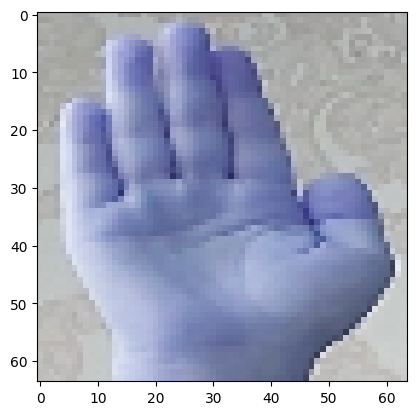

In [27]:
plt.imshow(random.sample(images, 1)[0])

## split data set into train and test

x is for the actual data, y is for the label (this is convention)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

400
100
400
100


## transform data sets into a format compatible with our neural network

image data has to be a numpy array with following dimensions: [image_id, y_axis, x_axis, color_channels]

furthermore, scale all values to a range of 0 to 1

training data has to be converted to a categorial vector ("one hot"):

[3] --> [0, 0, 0, 1, 0, ..., 0]

In [29]:
X_train = np.array(X_train).astype('float32')
X_train = X_train / 255.

X_test = np.array(X_test).astype('float32')
X_test = X_test / 255.

y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)

train_label = y_train_one_hot
test_label = y_test_one_hot

X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)
X_test = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)

print(X_train.shape, X_test.shape, train_label.shape, test_label.shape)

(400, 64, 64, 3) (100, 64, 64, 3) (400, 2) (100, 2)


## Testing hyperparameter number of neurons

### Chosen values
- 16
- 32
- 64
- 128
- 256

64 was standard in this notebook so I used the logarithmic scale to choose 4 other values with 64 in the middle


### Approach
- use the same test/train split
- keep all the other parameters the same
- models will be compared using accuracy, validation accuracy and inference time


### Assumption
- 16 underfits
- 32 underfits but not as bad
- 64 should be fine
- 128 starts overfitting
- 256 overfits

In [30]:
# hyperparameters to try out
# chosen because standard is 64 in this notebook -> 16, 32, 64, 128, 256 because of x^2
# assumption: 16 and 32 are underfiting, 128 and 256 are overfitting
num_neurons_selection = [16, 32, 64, 128, 256]

In [31]:
# logic from base notebook with variable for number of neurons

def build_model(num_neurons):

    num_classes = len(label_names)
    activation = 'relu'
    activation_conv = 'LeakyReLU'  # LeakyReLU doesn't work -> relu is used
    layer_count = 2

    # define model structure
    # with keras, we can use a model's add() function to add layers to the network one by one
    model = Sequential()
    
    # data augmentation (this can also be done beforehand - but don't augment the test dataset!)
    model.add(RandomFlip('horizontal'))
    model.add(RandomContrast(0.1))
    #model.add(RandomBrightness(0.1))
    #model.add(RandomRotation(0.2))
    
    # first, we add some convolution layers followed by max pooling
    model.add(Conv2D(64, kernel_size=(9, 9), activation=activation, input_shape=(SIZE[0], SIZE[1], COLOR_CHANNELS), padding='same'))
    model.add(MaxPooling2D(pool_size=(4, 4), padding='same'))
    
    model.add(Conv2D(32, (5, 5), activation=activation, padding='same'))
    model.add(MaxPooling2D(pool_size=(3, 3), padding='same'))
    
    model.add(Conv2D(32, (3, 3), activation=activation, padding='same'))
    model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))
    
    # dropout layers can drop part of the data during each epoch - this prevents overfitting
    model.add(Dropout(0.2))
    
    # after the convolution layers, we have to flatten the data so it can be fed into fully connected layers
    model.add(Flatten())
    
    # add some fully connected layers ("Dense")
    for i in range(layer_count - 1):
        model.add(Dense(num_neurons, activation=activation))
    
    model.add(Dense(num_neurons, activation=activation))
        
    # for classification, the last layer has to use the softmax activation function, which gives us probabilities for each category
    model.add(Dense(num_classes, activation='softmax'))

    # specify loss function, optimizer and evaluation metrics
    # for classification, categorial crossentropy is used as a loss function
    # use the adam optimizer unless you have a good reason not to
    model.compile(loss=categorical_crossentropy, optimizer="adam", metrics=['accuracy'])

    return model

In [ ]:
# all the models are trained and saved in here
models = {}

batch_size = 8
epochs = 50

for num_neurons in num_neurons_selection:

    # define callback functions that react to the model's behavior during training
    # in this example, we reduce the learning rate once we get stuck and early stopping
    # to cancel the training if there are no improvements for a certain amount of epochs
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)
    stop_early = EarlyStopping(monitor='val_loss', patience=3)

    model = build_model(num_neurons)

    history = model.fit(
        X_train,
        train_label,
        batch_size=batch_size,
        epochs=epochs,
        verbose=1,
        validation_data=(X_test, test_label),
        callbacks=[reduce_lr, stop_early]
    )

    # model and history saved for evaluation
    models[num_neurons] = (model, history)

Epoch 1/50


e:\Uni\ITT\assignment-05-cnn-GixD42\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5200 - loss: 0.6961 - val_accuracy: 0.4600 - val_loss: 0.7089 - learning_rate: 0.0010
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5600 - loss: 0.6871 - val_accuracy: 0.5100 - val_loss: 0.6562 - learning_rate: 0.0010
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6525 - loss: 0.6090 - val_accuracy: 0.4700 - val_loss: 0.6837 - learning_rate: 0.0010
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7450 - loss: 0.5001 - val_accuracy: 0.8100 - val_loss: 0.4112 - learning_rate: 0.0010
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8400 - loss: 0.3929 - val_accuracy: 0.8700 - val_loss: 0.3214 - learning_rate: 0.0010
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8750 - loss: 0.2915 - val_accuracy: 0.9200 - val_loss: 0.1670 - learning_rate: 0.0010
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8950 - loss: 0.2444 - val_accuracy: 0.9900 - v

In [ ]:
# summary for all models
for num_neurons, (model, history) in models.items():
    model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_5 (RandomFlip)      │ (8, 64, 64, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_5               │ (8, 64, 64, 3)         │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (8, 64, 64, 64)        │        15,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (8, 16, 16, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (8, 16, 16, 32)        │        51,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (8, 6, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (8, 6, 6, 32)          │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (8, 3, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (8, 3, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (8, 288)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (8, 16)                │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (8, 16)                │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (8, 2)                 │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,080 (949.54 KB)

 Trainable params: 81,026 (316.51 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_9 (RandomFlip)      │ (8, 64, 64, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_9               │ (8, 64, 64, 3)         │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (8, 64, 64, 64)        │        15,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (8, 16, 16, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (8, 16, 16, 32)        │        51,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (8, 6, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (8, 6, 6, 32)          │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (8, 3, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (8, 3, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (8, 288)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (8, 256)               │        73,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (8, 256)               │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (8, 2)                 │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649,160 (2.48 MB)

 Trainable params: 216,386 (845.26 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 432,774 (1.65 MB)

In [34]:
import time

In [ ]:
# all the metrics used for later
losses = {}
val_losses = {}
accuracies = {}
val_accuracies = {}
inference_times = {}
confusion_matrixs = {}

# evaluate all models and store metrics
for num_neurons, (model, history) in models.items():
    losses[num_neurons] = history.history['loss']
    val_losses[num_neurons] = history.history['val_loss']
    accuracies[num_neurons] = history.history['accuracy']
    val_accuracies[num_neurons] = history.history['val_accuracy']

    # simple inference time measurement
    t0 = time.time()
    y_predictions = model.predict(X_test)
    t1 = time.time()
    inference_times[num_neurons] = (t1 - t0) / len(X_test) * 1000 # time per sample in ms

    # for confusion matrix
    y_predictions = np.argmax(y_predictions, axis=1)

    conf_matrix = confusion_matrix(y_test, y_predictions)
    confusion_matrixs[num_neurons] = conf_matrix

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


### Inference Times

In [36]:
inference_times

{16: 1.398026943206787,
 32: 1.3620853424072266,
 64: 1.3842535018920898,
 128: 1.3257551193237305,
 256: 1.352524757385254}

The inference times are very similar

Plots

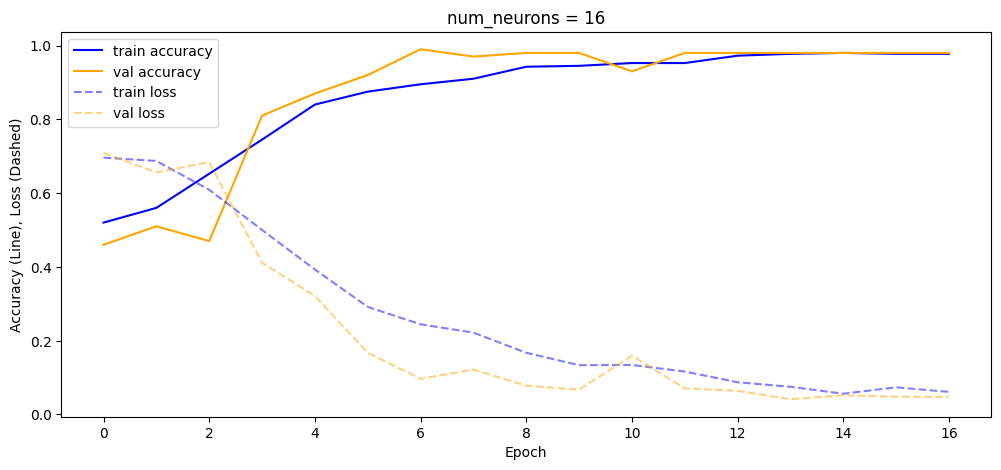

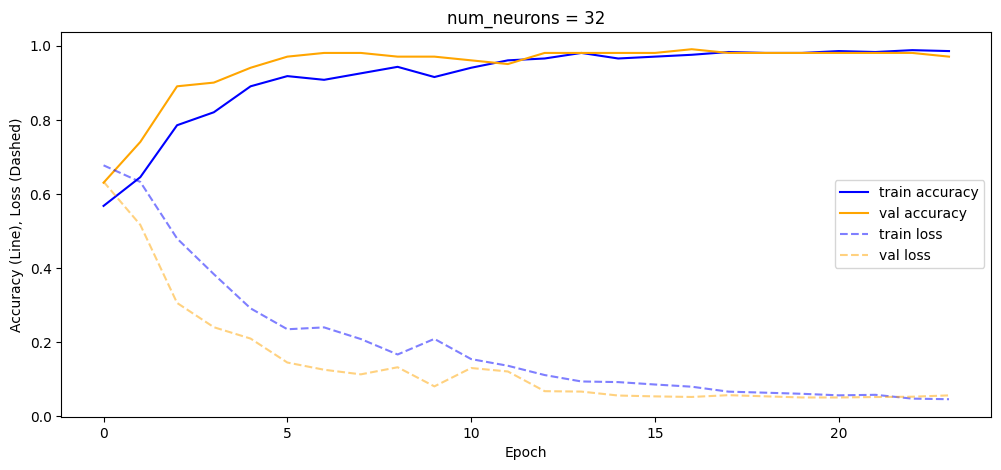

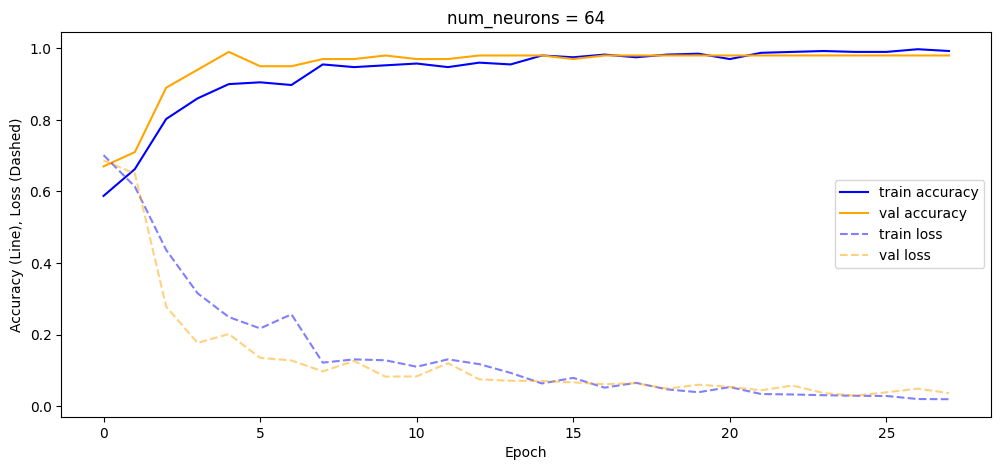

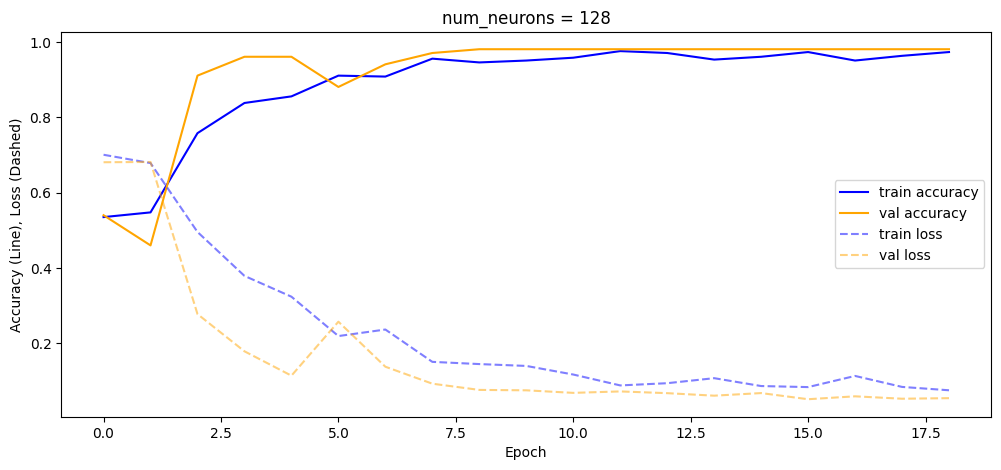

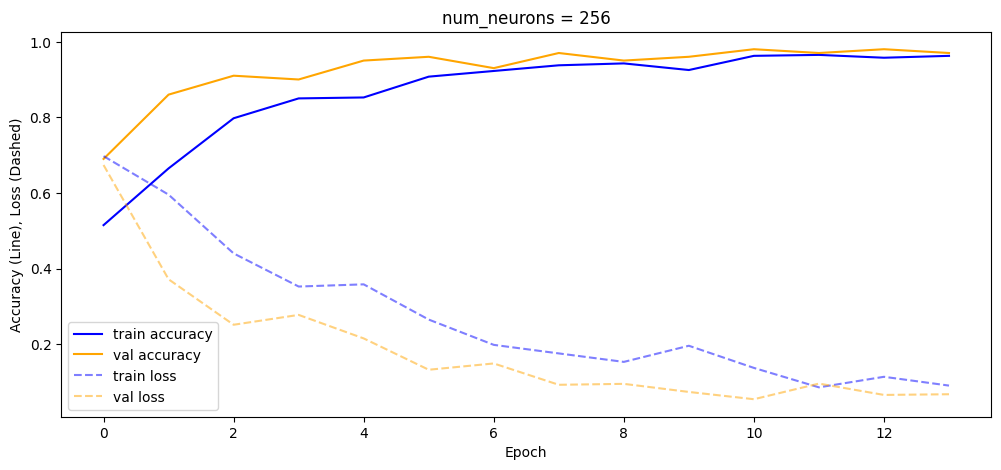

In [ ]:
# plots for all models
for num_neurons, (model, history) in models.items():
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']

    fig = plt.figure(figsize=(12, 5))
    ax = plt.gca()

    ax.set_title(f'num_neurons = {num_neurons}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (Line), Loss (Dashed)')

    plt.plot(accuracy, label='train accuracy', color='blue')
    plt.plot(val_accuracy, label='val accuracy', color='orange')
    plt.plot(loss, '--', label='train loss', color='blue', alpha=0.5)
    plt.plot(val_loss, '--', label='val loss', color='orange', alpha=0.5)
    plt.legend()
    plt.show()

### confusion matrices

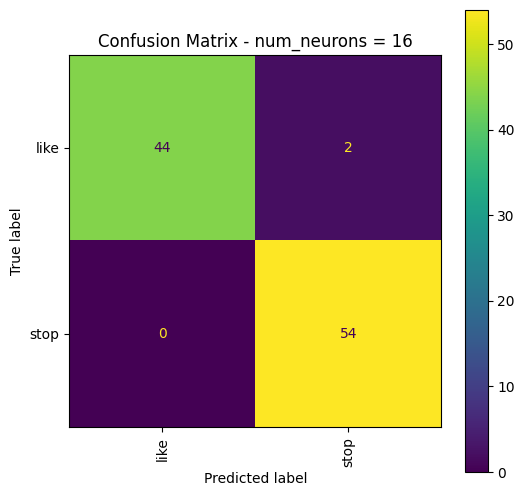

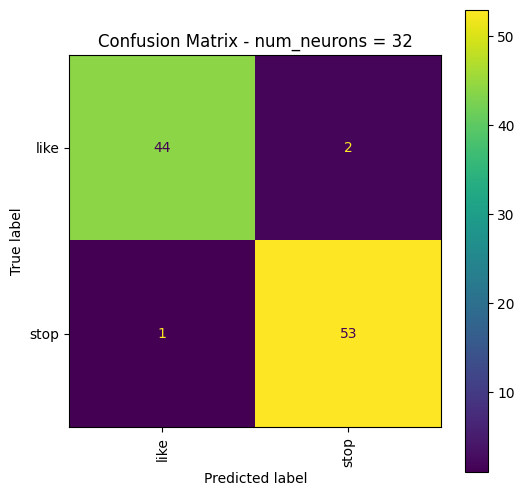

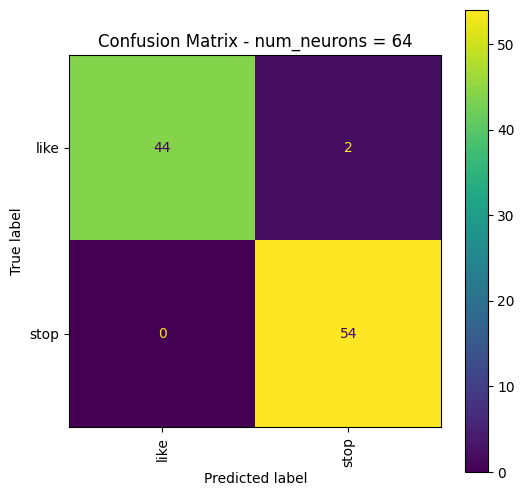

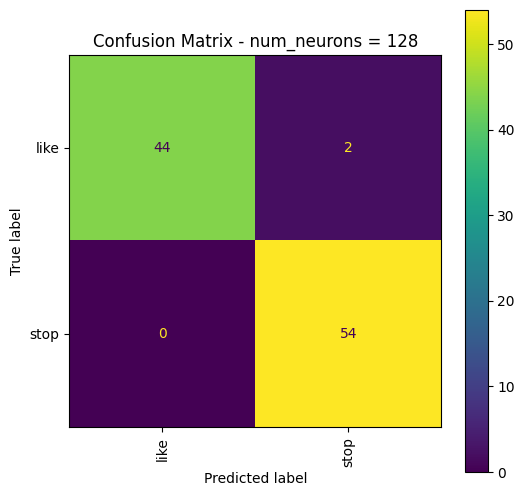

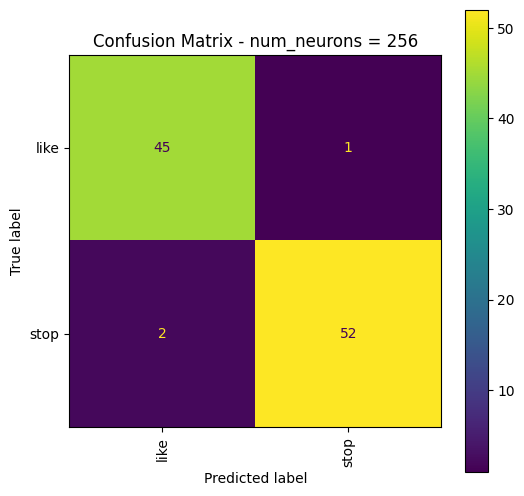

In [ ]:
# confusion matrices for all models
for num_neurons, conf_matrix in confusion_matrixs.items():
    fig = plt.figure(figsize=(6, 6))
    ConfusionMatrixDisplay(conf_matrix, display_labels=label_names).plot(ax=plt.gca())
    plt.title(f'Confusion Matrix - num_neurons = {num_neurons}')
    plt.xticks(rotation=90, ha='center')
    plt.show()

In [39]:
import pandas as pd

In [ ]:
# create dataframe for better overview

rows = []

for num_neurons in sorted(models.keys()):
    rows.append({
        "num_neurons": num_neurons,
        "epochs_ran": len(accuracies[num_neurons]),
        "final_train_acc": accuracies[num_neurons][-1],
        "best_train_acc": max(accuracies[num_neurons]),
        "final_val_acc": val_accuracies[num_neurons][-1],
        "best_val_acc": max(val_accuracies[num_neurons]),
        "final_train_loss": losses[num_neurons][-1],
        "final_val_loss": val_losses[num_neurons][-1],
        "best_val_loss": min(val_losses[num_neurons]),
        "inference_ms_per_sample": inference_times[num_neurons],
    })

results_df = pd.DataFrame(rows).sort_values("num_neurons")
results_df

,num_neurons,epochs_ran,final_train_acc,best_train_acc,final_val_acc,best_val_acc,final_train_loss,final_val_loss,best_val_loss,inference_ms_per_sample
0,16,17,0.9775,0.9800,0.98,0.99,0.061141,0.047881,0.041287,1.398027
1,32,24,0.9850,0.9875,0.97,0.99,0.046137,0.056480,0.050808,1.362085
2,64,28,0.9925,0.9975,0.98,0.99,0.019263,0.036387,0.029359,1.384254
3,128,19,0.9725,0.9750,0.98,0.98,0.075944,0.055049,0.052246,1.325755
4,256,14,0.9625,0.9650,0.97,0.98,0.090818,0.067950,0.054785,1.352525


# Analysis

## Inference Time

The inference time is pretty similar between all the models this suggests that the number of neurons don't really have an impact on it.<br>
Since the times are so quick it may be possible that small differences are caused by random circumstances.

## Epochs

The number of Epochs has it's maximum at 64 neurons so this model had more time adjusting. The others seemed to reach a plateau faster.

## Accuracies

Final train accuracy and best train accuracy are best with 64 number of neurons and the closer the number of neurons is, the better the results are.<br>
For the final val accuracy 16, 64 and 128 had the best scores. For the best val accuracy 16, 32 and 64  had the best scores.

## Losses

The final train losses are least with 64 neurons and again the further away we go from the 64, the higher the loss goes.<br>
The final val losses behave the similar but the second lowest is with 16 neurons.<br>
For the best val losses again it's best with 64 neurons.

## Confusion Matrices

The models with 16, 64 and 128 only had 2 wrongly classified pictures the other 2 had 3.<br>
All in all it seems all of them a pretty stable

# Conclusion

For this hyperparameter 64 seems to be the one with the best results in all the categories.